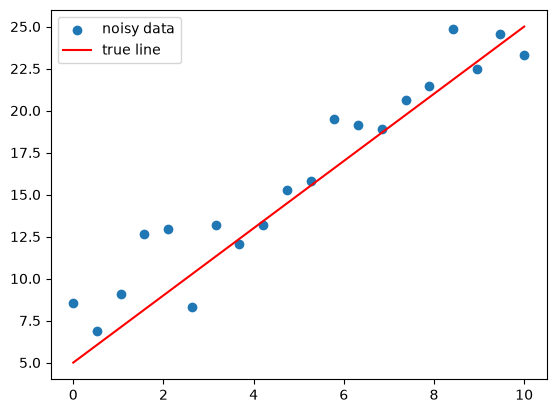

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# The TRUE line — we pick these, so we know the answer
m_true = 2.0
b_true = 5.0

# Fake measurements: 20 x-points, y = m*x + b + noise
np.random.seed(0)
x = np.linspace(0, 10, 20)
noise = np.random.normal(0, 2.0, size=20)
y = m_true * x + b_true + noise

plt.scatter(x, y, label="noisy data")
plt.plot(x, m_true*x + b_true, 'r-', label="true line")
plt.legend()
plt.show()

In [3]:
def sum_sq_resid(m, b):
    y_pred = m * x + b
    residuals = y - y_pred
    return np.sum(residuals**2)

print("true (m=2, b=5):", sum_sq_resid(2.0, 5.0))
print("bad guess (m=0, b=0):", sum_sq_resid(0.0, 0.0))

true (m=2, b=5): 83.75621382557193
bad guess (m=0, b=0): 5836.20865196583


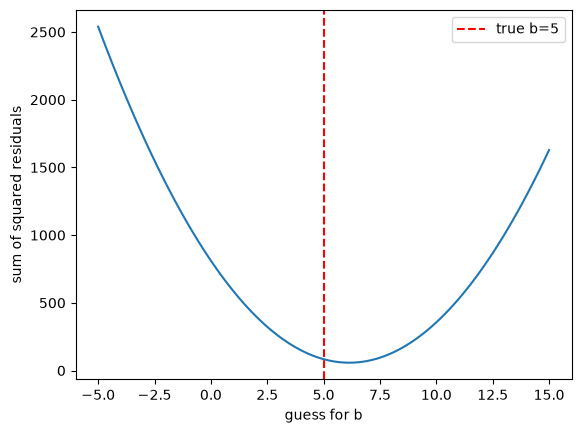

In [4]:
b_values = np.linspace(-5, 15, 100)
scores = [sum_sq_resid(2.0, b) for b in b_values]

plt.plot(b_values, scores)
plt.axvline(5.0, color='r', linestyle='--', label='true b=5')
plt.xlabel("guess for b")
plt.ylabel("sum of squared residuals")
plt.legend()
plt.show()

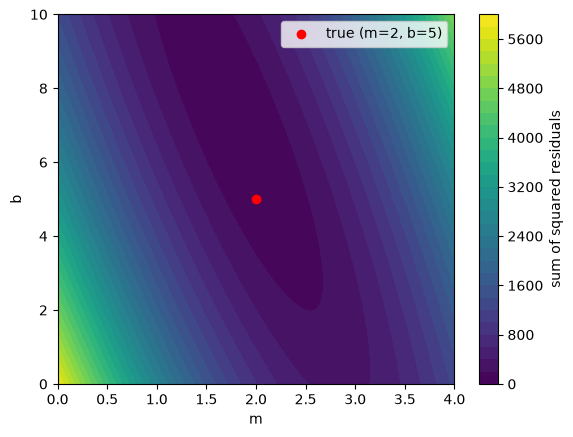

In [5]:
m_grid = np.linspace(0, 4, 100)
b_grid = np.linspace(0, 10, 100)
M, B = np.meshgrid(m_grid, b_grid)

Z = np.zeros_like(M)
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        Z[i, j] = sum_sq_resid(M[i, j], B[i, j])

plt.contourf(M, B, Z, levels=30)
plt.colorbar(label="sum of squared residuals")
plt.scatter([2.0], [5.0], color='red', label='true (m=2, b=5)')
plt.xlabel("m")
plt.ylabel("b")
plt.legend()
plt.show()

In [6]:
def gradient(m, b, eps=1e-5):
    # how much does score change if we nudge m a tiny bit?
    dm = (sum_sq_resid(m + eps, b) - sum_sq_resid(m, b)) / eps
    # how much does score change if we nudge b a tiny bit?
    db = (sum_sq_resid(m, b + eps) - sum_sq_resid(m, b)) / eps
    return dm, db

print(gradient(0.0, 0.0))

(np.float64(-3880.7735109003256), np.float64(-645.5465673752769))


In [7]:
m, b = 0.0, 0.0
lr = 0.001

for i in range(2000):
    dm, db = gradient(m, b)
    m = m - lr * dm
    b = b - lr * db
    if i % 400 == 0:
        print(f"step {i}: m={m:.3f}, b={b:.3f}, score={sum_sq_resid(m, b):.2f}")

print(f"\nrecovered: m={m:.3f}, b={b:.3f}")
print(f"truth:     m=2.000, b=5.000")

step 0: m=3.881, b=0.646, score=1172.91
step 400: m=1.787, b=7.178, score=48.35
step 800: m=1.773, b=7.275, score=48.30
step 1200: m=1.773, b=7.276, score=48.30
step 1600: m=1.773, b=7.276, score=48.30

recovered: m=1.773, b=7.276
truth:     m=2.000, b=5.000


In [8]:
import emcee

noise_sigma = 2.0   # the noise std we used to make the data

def log_prob(params):
    m, b = params
    return -0.5 * sum_sq_resid(m, b) / noise_sigma**2

print("log_prob at true (2,5):", log_prob([2.0, 5.0]))
print("log_prob at bad (0,0):", log_prob([0.0, 0.0]))

log_prob at true (2,5): -10.469526728196492
log_prob at bad (0,0): -729.5260814957287


In [9]:
import numpy as np

ndim = 2          # two parameters: m and b
nwalkers = 32     # 32 explorers
nsteps = 3000     # each takes 3000 steps

# scatter the walkers near a rough starting point (m≈1, b≈1)
start = np.array([1.0, 1.0]) + 0.1 * np.random.randn(nwalkers, ndim)

sampler = emcee.EnsembleSampler(nwalkers, ndim, log_prob)
sampler.run_mcmc(start, nsteps, progress=True)

print("done sampling")

You must install the tqdm library to use progress indicators with emcee


done sampling


In [10]:
# discard first 500 steps (burn-in), keep the rest, flatten all walkers together
samples = sampler.get_chain(discard=500, flat=True)

print("number of samples:", samples.shape[0])
print("m: mean =", samples[:,0].mean().round(3), " std =", samples[:,0].std().round(3))
print("b: mean =", samples[:,1].mean().round(3), " std =", samples[:,1].std().round(3))

number of samples: 80000
m: mean = 1.777  std = 0.146
b: mean = 7.254  std = 0.854


C:\Users\tdb33\miniforge3\envs\inv\Lib\site-packages\arviz\__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


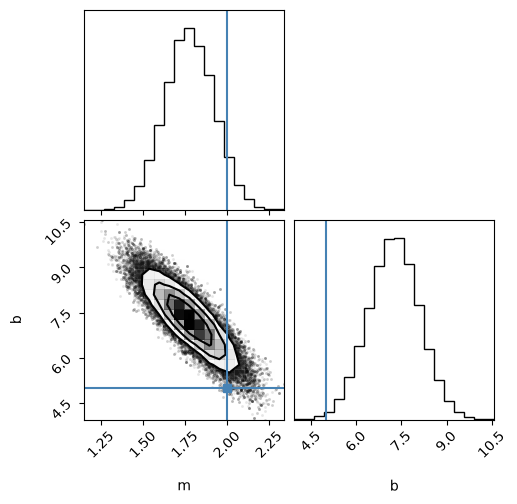

In [11]:
import corner

fig = corner.corner(samples, labels=["m", "b"], truths=[2.0, 5.0])

In [12]:
# ============================================================
# STEP 4: COVERAGE TEST
# Question: when the posterior says "90% interval," does the
# truth actually land inside 90% of the time?
# ============================================================

# --- the two functions, rewritten to TAKE data as arguments ---
# (this is the fix for the global-variable trap)
def sum_sq_resid_v2(m, b, x, y):
    y_pred = m * x + b
    return np.sum((y - y_pred)**2)

def log_prob_v2(params, x, y):
    m, b = params
    return -0.5 * sum_sq_resid_v2(m, b, x, y) / noise_sigma**2

# --- config ---
N_TRIALS = 200
rng = np.random.default_rng(42)   # one controlled random source

# counters: did the truth land inside this trial's 90% interval?
hits_m = 0
hits_b = 0

for i in range(N_TRIALS):
    # 1. FRESH DATA: new noise every trial (this is what breaks the trap)
    y_trial = m_true * x + b_true + rng.normal(0, noise_sigma, size=len(x))

    # 2. fit THIS dataset — args=(x, y_trial) hands the data to the sampler
    start = np.array([1.0, 1.0]) + 0.1 * rng.standard_normal((nwalkers, ndim))
    sampler = emcee.EnsembleSampler(
        nwalkers, ndim, log_prob_v2, args=(x, y_trial)
    )
    sampler.run_mcmc(start, nsteps, progress=False)
    samples = sampler.get_chain(discard=500, flat=True)

    # 3. COVERAGE CHECK: central 90% interval = 5th to 95th percentile
    m_lo, m_hi = np.percentile(samples[:, 0], [5, 95])
    b_lo, b_hi = np.percentile(samples[:, 1], [5, 95])

    # did the TRUE value land inside?
    if m_lo <= m_true <= m_hi:
        hits_m += 1
    if b_lo <= b_true <= b_hi:
        hits_b += 1

    if (i + 1) % 20 == 0:
        print(f"[{i+1:3d}/{N_TRIALS}]  m-coverage so far: {hits_m/(i+1):.3f}   b-coverage so far: {hits_b/(i+1):.3f}")

# --- results with the binomial error bar ---
cov_m = hits_m / N_TRIALS
cov_b = hits_b / N_TRIALS
se_m = np.sqrt(cov_m * (1 - cov_m) / N_TRIALS)
se_b = np.sqrt(cov_b * (1 - cov_b) / N_TRIALS)

print("\n" + "="*50)
print(f"m coverage: {cov_m:.3f} ± {se_m:.3f}   (nominal 0.90)")
print(f"b coverage: {cov_b:.3f} ± {se_b:.3f}   (nominal 0.90)")
print("="*50)
print(f"m PASS if 0.90 in [{cov_m-2*se_m:.3f}, {cov_m+2*se_m:.3f}]: {cov_m-2*se_m <= 0.90 <= cov_m+2*se_m}")
print(f"b PASS if 0.90 in [{cov_b-2*se_b:.3f}, {cov_b+2*se_b:.3f}]: {cov_b-2*se_b <= 0.90 <= cov_b+2*se_b}")

[ 20/200]  m-coverage so far: 0.850   b-coverage so far: 0.800
[ 40/200]  m-coverage so far: 0.900   b-coverage so far: 0.875
[ 60/200]  m-coverage so far: 0.900   b-coverage so far: 0.917
[ 80/200]  m-coverage so far: 0.925   b-coverage so far: 0.925
[100/200]  m-coverage so far: 0.900   b-coverage so far: 0.930
[120/200]  m-coverage so far: 0.900   b-coverage so far: 0.925
[140/200]  m-coverage so far: 0.914   b-coverage so far: 0.936
[160/200]  m-coverage so far: 0.912   b-coverage so far: 0.938
[180/200]  m-coverage so far: 0.911   b-coverage so far: 0.928
[200/200]  m-coverage so far: 0.915   b-coverage so far: 0.920

m coverage: 0.915 ± 0.020   (nominal 0.90)
b coverage: 0.920 ± 0.019   (nominal 0.90)
m PASS if 0.90 in [0.876, 0.954]: True
b PASS if 0.90 in [0.882, 0.958]: True
